In [83]:
import nasdaqdatalink as ndl
import pandas as pd
from ta import add_all_ta_features
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

from itertools import product
from tqdm.notebook import tqdm
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import random
import os

def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)





In [26]:
#configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [84]:
data_base = pd.read_csv('../data/data_base.csv', parse_dates=['date'])

In [69]:
data_base.columns

Index(['ticker', 'date', 'vol_1y', 'max_1y', 'min_1y', 'sma_1y', 'sma_2y',
       'volatility_1y', 'revenue', 'eps', 'ebitda', 'netinc', 'roe',
       'evebitda', 'fcfps', 'pb', 'pe', 'marketcap', 'ebit', 'capex', 'ncfo',
       'equity', 'de', 'target_12m_final', 'target_class'],
      dtype='object')

En este caso la red neuronal funcionan mejor 

Parece que hay mejores resultados al eliminar variables brutas (sobre las que ya hemos generado variables más avanzadas o combinadas)

In [85]:
data_base.drop(columns=['cap_category'], inplace=True)




In [66]:
data_base.drop(columns=['revenue_yoy', 'ebitda_yoy', 'ebit_yoy', 'eps_yoy',
       'equity_yoy', 'capex_yoy', 'pe_yoy', 'pb_yoy', 'fcfps_yoy', 'ncfo_yoy',
       'closeadj', 'ret_6m', 'ret_12m', 'risk_free_rate','signed_log_revenue', 'signed_log_ebitda', 'signed_log_ebit',
       'signed_log_marketcap', 'signed_log_equity', 'ebit_margin',
       'net_margin', 'capex_to_revenue', 'fcf_yield', 'ps', 'ret_12m_vol',
       'ret_6m_vol', 'sma_diff', 'dist_max_1y', 'dist_min_1y', 'vol_over_sma',
       'cap_category', 'cap_Large Cap', 'cap_Mega Cap', 'cap_Mid Cap',
       'cap_Small Cap'], inplace=True)

In [57]:
data_base.drop(columns=['cap_category', 'closeadj', 'max_1y', 'min_1y', 'marketcap','revenue', 'eps', 'ebitda', 'netinc',
                    'revenue', 'eps', 'ebitda', 'netinc', 'ebit',   ], inplace=True)

---------------------------------------------------------------------------------------------------------------------------------


best model, ventanas expansivas y validación de parámetros:

In [86]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from collections import defaultdict

# Fijar semilla
def set_seed(seed=42):
    import random, os, tensorflow as tf
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(42)

# Preparar datos
df = data_base.copy()
df.sort_values(by=['ticker', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)
df['date'] = pd.to_datetime(df['date'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

features = [col for col in df.columns if col not in ['target_class', 'date', 'ticker', 'target_12m_final']]
target = 'target_class'

# Folds de validación
df_cv = df[(df['date'].dt.year >= 1999) & (df['date'].dt.year <= 2003)]
folds = {year: df_cv[df_cv['date'].dt.year == year] for year in range(1999, 2004)}


In [87]:
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=(len(features),)))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=64, max_value=256, step=64),
            activation='relu'
        ))
    model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(5, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(hp.Float('lr', 1e-4, 1e-2, sampling='log')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [88]:
set_seed(42)


results = []

param_trials = 20
executions_per_trial = 1

for i in range(1, 5):
    train_years = list(range(1999, 1999 + i))
    val_year = 1999 + i

    train_df = pd.concat([folds[y] for y in train_years])
    val_df = folds[val_year]

    X_train = train_df[features].copy()
    X_val = val_df[features].copy()

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    y_train = keras.utils.to_categorical(train_df[target], num_classes=5)
    y_val = keras.utils.to_categorical(val_df[target], num_classes=5)
    y_val_true = val_df[target].values

    tuner = kt.RandomSearch(
        build_model,
        objective='val_accuracy',  # solo para guía interna
        max_trials=param_trials,
        executions_per_trial=executions_per_trial,
        overwrite=True,
        directory='tuner_dnn',
        project_name=f'dnn_cv_{val_year}'
    )

    early_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    tuner.search(X_train, y_train,
                 epochs=20,
                 validation_data=(X_val, y_val),
                 verbose=0,
                 callbacks=[early_cb])

    best_model = tuner.get_best_models(1)[0]
    y_val_pred = np.argmax(best_model.predict(X_val), axis=1)

    try:
        precision_4 = precision_score(y_val_true, y_val_pred, average=None, labels=[4])[0]
    except IndexError:
        precision_4 = 0.0

    best_hp = tuner.get_best_hyperparameters(1)[0]

    results.append({
        'val_year': val_year,
        'precision_4': precision_4,
        'params': best_hp.values
    })

results_val_df = pd.DataFrame(results)
display(results_val_df.sort_values('precision_4', ascending=False))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


c:\Users\Ignacio\sp500_env\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


c:\Users\Ignacio\sp500_env\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


c:\Users\Ignacio\sp500_env\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


c:\Users\Ignacio\sp500_env\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,val_year,precision_4,params
0,2000,0.409091,"{'num_layers': 3, 'units_0': 256, 'dropout': 0..."
3,2003,0.327273,"{'num_layers': 1, 'units_0': 128, 'dropout': 0..."
1,2001,0.308725,"{'num_layers': 1, 'units_0': 192, 'dropout': 0..."
2,2002,0.228571,"{'num_layers': 2, 'units_0': 256, 'dropout': 0..."


In [47]:
best_hp

In [89]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from collections import defaultdict


set_seed(42)

# Suponemos que ya tenés best_hp definido a partir del tuner
# Por ejemplo, tomamos el mejor global del DataFrame anterior:
best_hp = results_val_df.sort_values('precision_4', ascending=False).iloc[0]['params']

results = []
selected_companies = defaultdict(list)
conf_matrix_total = np.zeros((5, 5), dtype=int)

for test_year in range(2004, 2025):
    train_start = 1999
    train_end = test_year - 1 

    train_df = df[(df['date'].dt.year >= train_start) & (df['date'].dt.year <= train_end)]
    test_df = df[df['date'].dt.year == test_year]

    if train_df.empty or test_df.empty:
        continue

    X_train = train_df[features].copy()
    X_test = test_df[features].copy()

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    y_train = keras.utils.to_categorical(train_df[target], num_classes=5)
    y_test_raw = test_df[target].values
    y_test = keras.utils.to_categorical(y_test_raw, num_classes=5)

    # Construcción del modelo con los mejores hiperparámetros
    model = keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))

    for i in range(best_hp['num_layers']):
        model.add(layers.Dense(best_hp[f'units_{i}'], activation='relu'))
    model.add(layers.Dropout(best_hp['dropout']))
    model.add(layers.Dense(5, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_hp['lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)

    y_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    # Métricas
    accuracy = accuracy_score(y_test_raw, y_pred)
    conf_mat = confusion_matrix(y_test_raw, y_pred, labels=[0, 1, 2, 3, 4])
    conf_matrix_total += conf_mat


    try:
        precision_4 = precision_score(y_test_raw, y_pred, average=None, labels=[4])[0]
        recall_4 = recall_score(y_test_raw, y_pred, average=None, labels=[4])[0]
    except IndexError:
        precision_4, recall_4 = 0.0, 0.0

    # Probabilidad clase 4 y top 20
    test_df = test_df.copy()
    test_df['proba_class_4'] = y_proba[:, 4]
    top20 = test_df.sort_values('proba_class_4', ascending=False).head(20)

    mean_return = top20['target_12m_final'].mean()
    volatility = top20['target_12m_final'].std()

    results.append({
        'year': test_year,
        'accuracy': accuracy,
        'precision_4': precision_4,
        'recall_4': recall_4,
        'mean_return_top20': mean_return,
        'volatility_top20': volatility,
        'n_class4_real': (test_df['target_class'] == 4).sum(),
        'confusion_matrix': conf_mat.tolist()
        
    })

    for _, row in top20.iterrows():
        selected_companies[test_year].append({
            'ticker': row['ticker'],
            'ret_12m': row['target_12m_final'],
            'proba_class_4': row['proba_class_4'],
            'target_class': row['target_class']  

        })

# Guardar métricas
results_df = pd.DataFrame(results)
results_df['cumulative_return'] = (1 + results_df['mean_return_top20']).cumprod()

print("📊 Métricas por año:")
display(results_df[[
    'year', 'accuracy', 'precision_4', 'recall_4',
    'mean_return_top20', 'volatility_top20',
    'n_class4_real', 'cumulative_return'
]])

# Empresas seleccionadas
empresas_df = []
for year, companies in selected_companies.items():
    for entry in companies:
        entry['year'] = year
        empresas_df.append(entry)
empresas_df = pd.DataFrame(empresas_df)


📊 Métricas por año:


,year,accuracy,precision_4,recall_4,mean_return_top20,volatility_top20,n_class4_real,cumulative_return
0,2004,0.202000,0.260000,0.130000,0.122692,0.518934,100,1.122692
1,2005,0.236000,0.252874,0.220000,0.243164,0.322806,100,1.395690
2,2006,0.198000,0.208696,0.240000,-0.005261,0.283288,100,1.388348
3,2007,0.244000,0.263158,0.250000,-0.042237,0.281924,100,1.329709
4,2008,0.184000,0.200000,0.080000,-0.516798,0.326457,100,0.642518
5,2009,0.242000,0.363014,0.530000,1.681821,1.946222,100,1.723117
6,2010,0.212425,0.131579,0.050000,0.174170,0.249908,100,2.023233
7,2011,0.234000,0.197183,0.140000,-0.008391,0.313178,100,2.006257
8,2012,0.236000,0.047619,0.010000,0.074164,0.251509,100,2.155048
9,2013,0.230000,0.342105,0.130000,0.398881,0.398246,100,3.014656


In [71]:

n_correct_class4 = (empresas_df['target_class'] == 4).sum()
precision_top20 = n_correct_class4 / len(empresas_df)
print(f"Precisión sobre top 20 seleccionadas: {precision_top20:.4f}")

results_df["precision_4"].mean()



Precisión sobre top 20 seleccionadas: 0.3071


np.float64(0.25881651912507514)

In [24]:
empresas_df[empresas_df["year"]==2009]

,ticker,ret_12m,proba_class_4,year
100,VRSN,0.378908,1.000000,2009
101,AIV,2.484733,0.999991,2009
102,WU,0.358213,0.997598,2009
103,GNW,8.652632,0.997387,2009
104,HBAN,2.277277,0.957436,2009
105,FITB,3.663436,0.895587,2009
106,TGNA,6.633588,0.873323,2009
107,HIG,2.656120,0.855059,2009
108,AMD,2.039344,0.832561,2009
109,TNL,5.208507,0.817189,2009


### Guardar los resultados para comparar con los otros modelos

In [ ]:



# Guardar empresas predichas
empresas_df.to_csv('../result_metrics/tickers_dnn.csv', index=False)


# Guardar metricas
results_df.to_csv('../result_metrics/metrics_dnn.csv', index=False)

# Guardar matriz de confusión total como CSV
conf_df = pd.DataFrame(conf_matrix_total,
                       index=[f"True_{i}" for i in range(5)],
                       columns=[f"Pred_{i}" for i in range(5)])
conf_df.to_csv("../result_metrics/cm_dnn.csv")



In [27]:
data_base[data_base["ticker"]=="KDP"]

,ticker,date,vol_1y,sma_1y,sma_2y,volatility_1y,roe,evebitda,fcfps,pb,pe,capex,ncfo,equity,de,revenue_yoy,ebitda_yoy,ebit_yoy,eps_yoy,equity_yoy,capex_yoy,pe_yoy,pb_yoy,fcfps_yoy,ncfo_yoy,ret_6m,ret_12m,risk_free_rate,target_12m_final,signed_log_revenue,signed_log_ebitda,signed_log_ebit,signed_log_marketcap,signed_log_equity,ebit_margin,net_margin,capex_to_revenue,fcf_yield,ps,ret_12m_vol,ret_6m_vol,sma_diff,dist_max_1y,dist_min_1y,vol_over_sma,cap_Large Cap,cap_Mega Cap,cap_Mid Cap,cap_Small Cap,target_class
6619,KDP,2009-03-31,7.019940e+08,2.410511,2.410511,0.517126,-0.088,99.290,1.610,1.740,-14.538,-300000000.0,7.090000e+08,2.607000e+09,2.313,-0.006611,-0.936342,-1.108209,0.057692,-0.480781,0.339286,-0.404756,-0.397664,0.077644,0.175788,-0.361628,-0.387721,0.026687,1.099852,22.465485,18.184958,-18.569101,22.235289,21.681466,-0.020315,-0.054641,-0.052539,0.795848,0.794378,-0.749761,-0.699305,0.000000,0.637567,1.420646,0.214529,False,False,False,True,3
6620,KDP,2010-03-31,5.338021e+08,3.132024,2.790096,0.307805,0.186,8.033,2.175,2.486,14.276,-312000000.0,8.650000e+08,3.187000e+09,1.754,-0.031349,15.708861,-10.594828,-2.772358,0.222478,0.040000,-1.981978,0.428736,0.350932,0.220028,0.234884,1.099852,0.038305,0.085452,22.433634,21.000898,20.830325,22.793077,21.882346,0.201229,0.100344,-0.056409,0.512006,1.432531,3.573212,0.763093,0.341928,0.955681,2.040346,0.098277,False,False,False,True,1
6621,KDP,2011-03-31,6.298368e+08,4.449996,3.792315,0.240257,0.193,8.350,9.597,3.261,15.186,-228000000.0,2.535000e+09,2.459000e+09,2.603,0.018984,-0.111364,-0.146451,0.004587,-0.228428,-0.269231,0.063743,0.311746,3.412414,1.930636,0.060244,0.085452,0.034716,0.118846,22.452440,20.882830,20.671973,22.804992,21.623021,0.168559,0.093683,-0.040454,2.081327,1.422693,0.355668,0.250747,0.657681,0.945846,1.166456,0.053990,False,False,False,True,3
6622,KDP,2012-03-31,4.981434e+08,4.863242,4.656210,0.220028,0.261,8.060,2.506,3.644,13.606,-212000000.0,7.600000e+08,2.263000e+09,3.102,0.047374,0.084399,0.094737,0.264840,-0.079707,-0.070175,-0.104043,0.117449,-0.738877,-0.700197,0.054795,0.118846,0.022175,0.205272,22.498727,20.963856,20.762487,22.832924,21.539957,0.176182,0.102660,-0.035914,0.485753,1.396818,0.540141,0.249034,0.207032,0.963579,1.178123,0.045243,False,False,False,True,3
6623,KDP,2013-03-31,4.202951e+08,5.665268,5.260653,0.162723,0.275,8.270,1.292,3.802,13.782,-186000000.0,4.580000e+08,2.280000e+09,2.916,0.015585,0.055818,0.060577,0.079422,0.007512,-0.122642,0.012935,0.043359,-0.484437,-0.397368,0.071699,0.205272,0.018508,0.198134,22.514192,21.018172,20.821300,22.882977,21.547441,0.183987,0.104921,-0.031026,0.207784,1.445977,1.261481,0.440622,0.404615,1.000000,1.238152,0.028723,False,False,True,False,2
6624,KDP,2014-03-31,3.542872e+08,6.406510,6.041727,0.152821,0.273,13.972,3.391,4.459,16.272,-178000000.0,8.660000e+08,2.277000e+09,2.602,0.000334,-0.329859,-0.396192,0.030100,-0.001316,-0.043011,0.180670,0.172804,1.624613,0.890830,0.234466,0.198134,0.027189,0.478255,22.514525,20.617905,20.316800,23.041104,21.546125,0.111056,0.104052,-0.029682,0.455168,1.693130,1.296514,1.534251,0.364783,1.000000,1.275467,0.023854,False,False,True,False,4
6625,KDP,2015-03-31,3.933952e+08,9.122718,7.761925,0.175969,0.307,12.304,4.392,6.580,21.470,-162000000.0,1.022000e+09,2.294000e+09,2.606,0.020677,0.575556,0.776276,0.165584,0.007466,-0.089888,0.319444,0.475667,0.295193,0.180139,0.234918,0.478255,0.019266,0.166894,22.534991,21.072513,20.891319,23.437533,21.553563,0.193269,0.114851,-0.026466,0.398801,2.465863,2.717843,1.335000,1.360794,0.985063,1.572612,0.019289,False,False,True,False,4
6626,KDP,2016-03-31,3.233788e+08,11.865968,10.498897,0.188087,0.345,12.908,4.358,7.903,22.583,-159000000.0,9.910000e+08,2.183000e+09,3.063,0.026303,0.077574,0.099746,0.114206,-0.048387,-0.018519,0.051840,0.201064,-0.007741,-0.030333,0.143734,0.166894,0.017704,0.121158,22.560954,21.147226,20.986399,23.571255,21.503966,0.207100,0.121617,-0.025310,0.339118,2.746428,0.887321,0.764191,1.

------------------------------------------------------------------------------------------------------------------------------------------------


best model, top20 class4, dnn, ventana expansiva, sin validación

In [17]:
data_base.drop(columns=["fcfps", "capex", "ncfo", "equity"], inplace=True)

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score

# Copia de la base original
df = data_base.copy()  # Esto funciona si data_base es un DataFrame
df.sort_values(by=['ticker', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)
# Asegurar tipo datetime
df['date'] = pd.to_datetime(df['date'])

# Limpieza de datos
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Filtro de años para búsqueda de hiperparámetros (rolling CV)
df_cv = df[(df['date'].dt.year >= 1999) & (df['date'].dt.year <= 2003)]

# Features y target
features = [col for col in df.columns if col not in ['target_class', 'date', 'ticker', 'target_12m_final']]
target = 'target_class'

# Crear folds por año
folds = {year: df_cv[df_cv['date'].dt.year == year] for year in range(1999, 2004)}


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix
from collections import defaultdict
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np

# Fijar Seed para reproducibilidad
set_seed(42)

# Configuración
n_years = 4
results = []
selected_companies = defaultdict(list)
feature_importance_by_year = {}  # No se usa con NN, se deja para compatibilidad

# Loop temporal
for test_year in range(2004, 2025):
    train_start = 1999 #Ventana expansiva
    train_end = test_year - 1

    train_df = df[(df['date'].dt.year >= train_start) & (df['date'].dt.year <= train_end)]
    test_df = df[df['date'].dt.year == test_year]

    if train_df.empty or test_df.empty:
        continue

    # Separar X e y
    X_train = train_df[features].copy()
    X_test = test_df[features].copy()

    # Normalización por separado (solo numéricas si aplica)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')

    y_train = keras.utils.to_categorical(train_df['target_class'], num_classes=5)
    y_test_raw = test_df['target_class'].values
    y_test = keras.utils.to_categorical(y_test_raw, num_classes=5)

    # Red neuronal simple
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(5, activation='softmax')  # 5 clases
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)

    y_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    # Métricas
    accuracy = accuracy_score(y_test_raw, y_pred)
    conf_mat = confusion_matrix(y_test_raw, y_pred, labels=[0, 1, 2, 3, 4])

    try:
        precision_4 = precision_score(y_test_raw, y_pred, average=None, labels=[4])[0]
        recall_4 = recall_score(y_test_raw, y_pred, average=None, labels=[4])[0]
    except IndexError:
        precision_4, recall_4 = 0.0, 0.0

    # Probabilidad clase 4 y top 20
    test_df = test_df.copy()
    test_df['proba_class_4'] = y_proba[:, 4]
    top20 = test_df.sort_values('proba_class_4', ascending=False).head(20)

    mean_return = top20['target_12m_final'].mean()
    volatility = top20['target_12m_final'].std()

    results.append({
        'year': test_year,
        'accuracy': accuracy,
        'precision_4': precision_4,
        'recall_4': recall_4,
        'mean_return_top20': mean_return,
        'volatility_top20': volatility,
        'n_class4_real': (test_df['target_class'] == 4).sum(),
        'confusion_matrix': conf_mat.tolist()
    })

    for _, row in top20.iterrows():
        selected_companies[test_year].append({
            'ticker': row['ticker'],
            'ret_12m': row['target_12m_final'],
            'proba_class_4': row['proba_class_4']
        })

# Convertir métricas a DataFrame
results_df = pd.DataFrame(results)
results_df['cumulative_return'] = (1 + results_df['mean_return_top20']).cumprod()

# Mostrar resumen
print("📊 Métricas por año:")
display(results_df[
    ['year', 'accuracy', 'precision_4', 'recall_4', 
     'mean_return_top20', 'volatility_top20', 
     'n_class4_real', 'cumulative_return']
])

# Guardar empresas seleccionadas
empresas_df = []
for year, companies in selected_companies.items():
    for entry in companies:
        entry['year'] = year
        empresas_df.append(entry)
empresas_df = pd.DataFrame(empresas_df)


📊 Métricas por año:


,year,accuracy,precision_4,recall_4,mean_return_top20,volatility_top20,n_class4_real,cumulative_return
0,2004,0.242000,0.263889,0.190000,0.191520,0.598349,100,1.191520
1,2005,0.278000,0.428571,0.330000,0.377673,0.322333,100,1.641525
2,2006,0.222000,0.232143,0.130000,0.186245,0.217663,100,1.947251
3,2007,0.202000,0.276923,0.180000,-0.102825,0.246422,100,1.747024
4,2008,0.160000,0.142857,0.070000,-0.479134,0.233057,100,0.909965
5,2009,0.236000,0.309013,0.720000,2.239835,2.303828,100,2.948136
6,2010,0.226453,0.205882,0.140000,0.321763,0.332344,100,3.896737
7,2011,0.206000,0.224138,0.130000,0.043937,0.307680,100,4.067949
8,2012,0.236000,0.333333,0.020000,0.161484,0.354986,100,4.724859
9,2013,0.208000,0.325581,0.140000,0.305634,0.332584,100,6.168937


In [20]:

#Precision top20 escogidas
top20 = test_df.sort_values('proba_class_4', ascending=False).head(20)
precision_at_20 = (top20['target_class'] == 4).sum() / 20
print(precision_at_20)
#Hit ratio
total_class4 = (test_df['target_class'] == 4).sum()
hits_in_top20 = (top20['target_class'] == 4).sum()
hit_ratio = hits_in_top20 / total_class4 if total_class4 > 0 else 0.0
print(hit_ratio)

#Matriz de confusión promedio
import numpy as np

# Suponiendo que results es tu lista con la clave 'confusion_matrix'
matrices = [np.array(r['confusion_matrix']) for r in results]
average_conf_matrix = np.mean(matrices, axis=0)

print("Matriz de confusión promedio:")
print(np.round(average_conf_matrix, 2))


0.2
0.039603960396039604
Matriz de confusión promedio:
[[37.71 18.95 14.9  15.57 13.33]
 [29.62 19.38 16.81 22.29 12.24]
 [27.14 20.81 18.19 21.86 12.33]
 [26.   21.71 19.38 20.62 12.62]
 [29.1  19.76 16.9  17.9  16.81]]


In [21]:
precision_at_20

np.float64(0.2)

In [22]:
data_base.columns

Index(['ticker', 'date', 'vol_1y', 'sma_1y', 'sma_2y', 'volatility_1y', 'roe',
       'evebitda', 'pb', 'pe', 'de', 'revenue_yoy', 'ebitda_yoy', 'ebit_yoy',
       'eps_yoy', 'equity_yoy', 'capex_yoy', 'pe_yoy', 'pb_yoy', 'fcfps_yoy',
       'ncfo_yoy', 'ret_6m', 'ret_12m', 'risk_free_rate', 'target_12m_final',
       'signed_log_revenue', 'signed_log_ebitda', 'signed_log_ebit',
       'signed_log_marketcap', 'signed_log_equity', 'ebit_margin',
       'net_margin', 'capex_to_revenue', 'fcf_yield', 'ps', 'ret_12m_vol',
       'ret_6m_vol', 'sma_diff', 'dist_max_1y', 'dist_min_1y', 'vol_over_sma',
       'cap_Large Cap', 'cap_Mega Cap', 'cap_Mid Cap', 'cap_Small Cap',
       'target_class'],
      dtype='object')

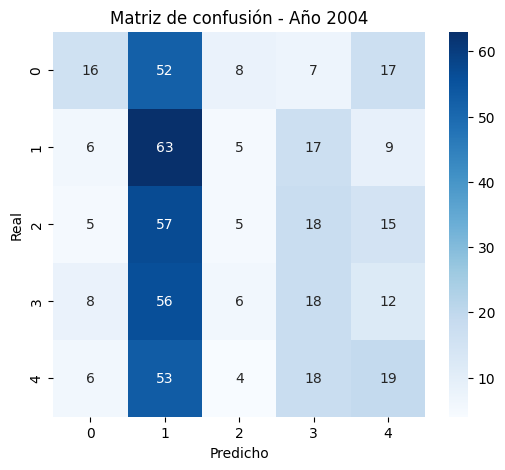

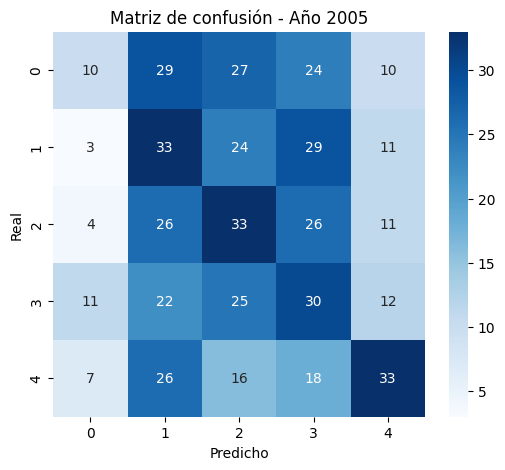

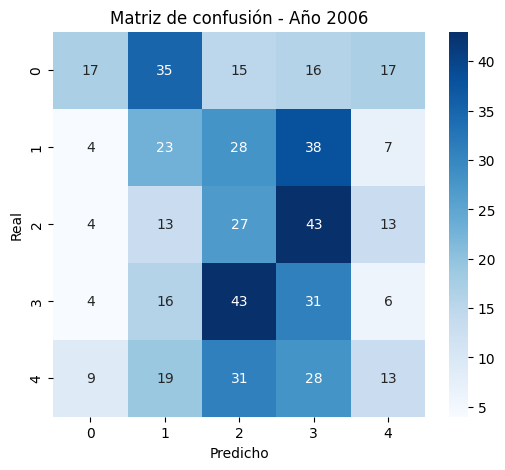

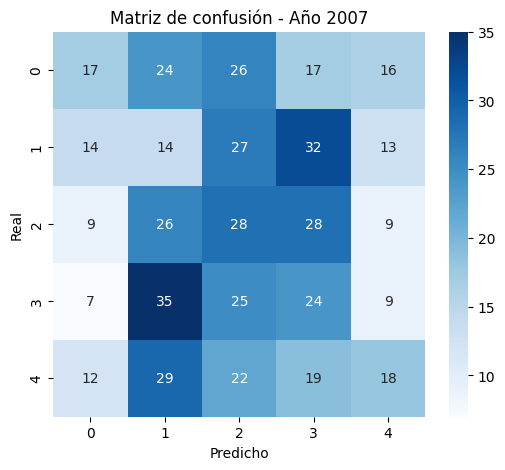

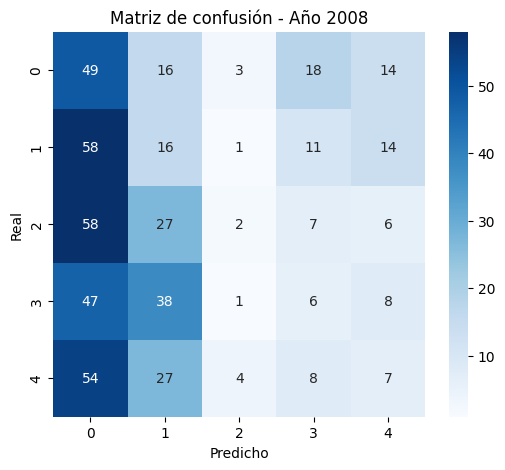

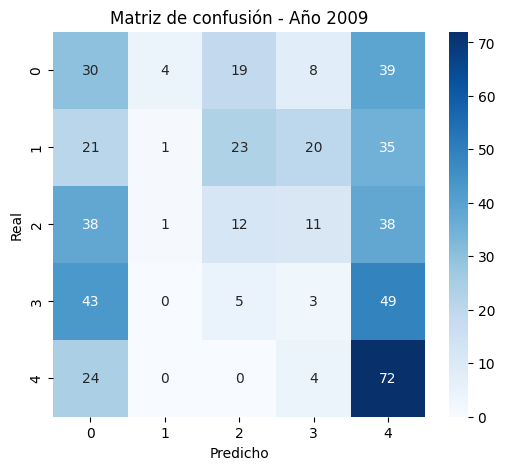

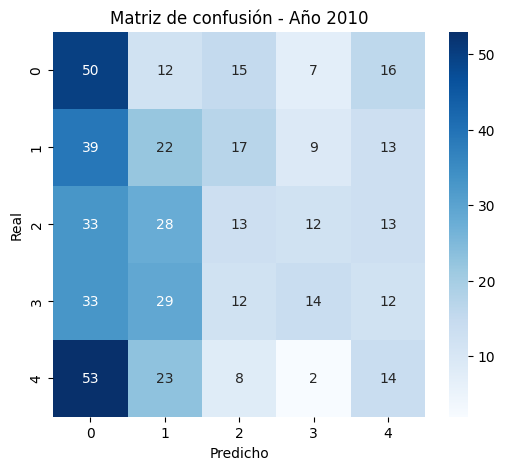

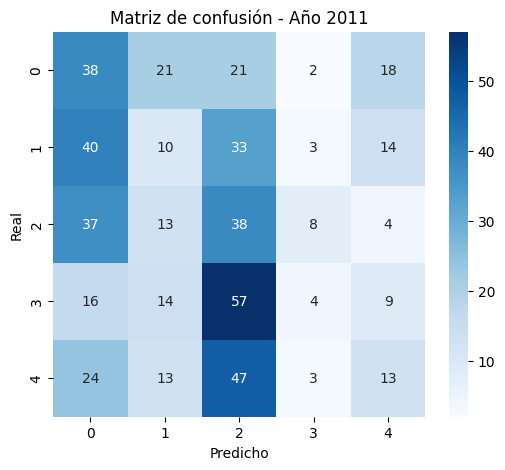

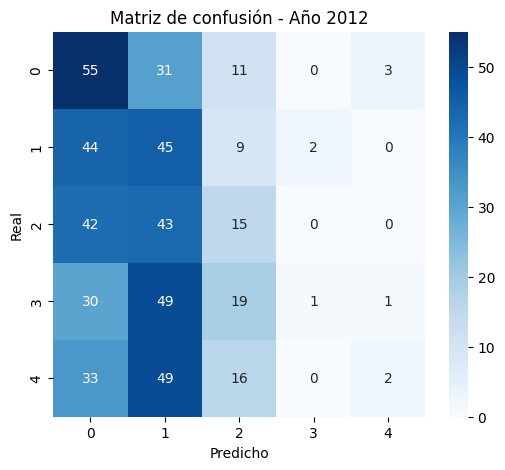

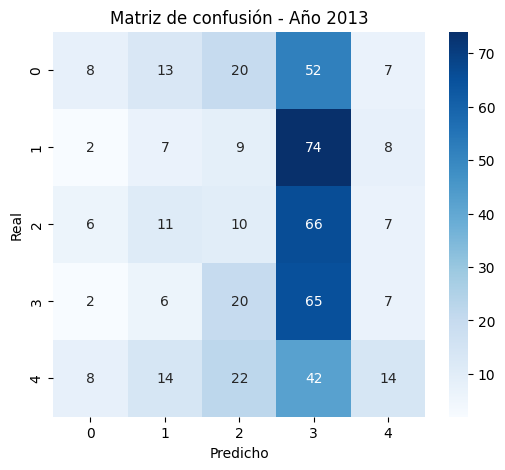

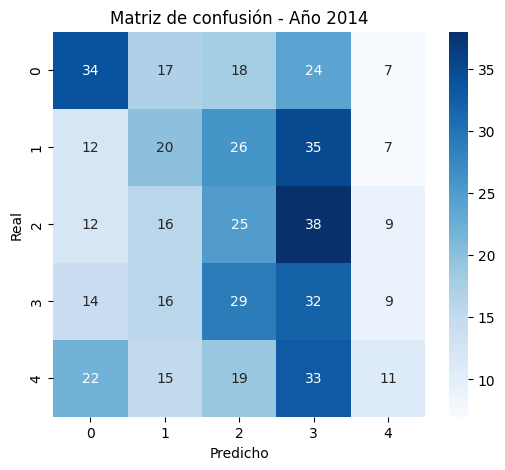

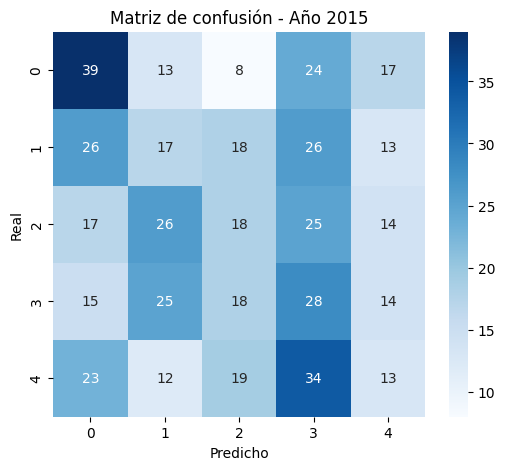

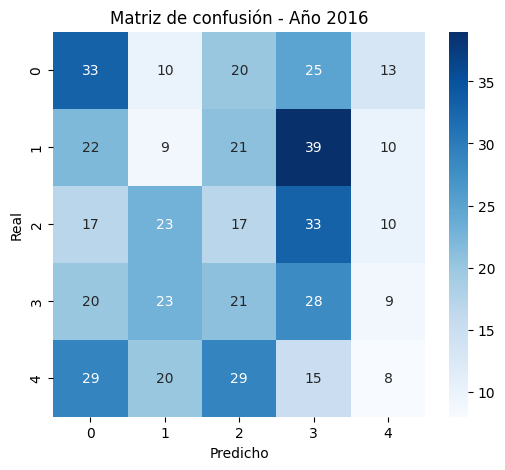

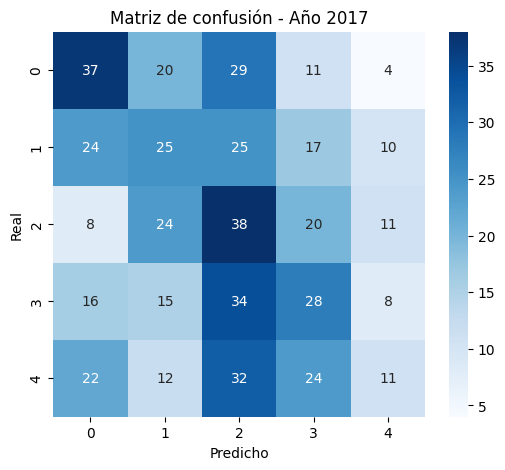

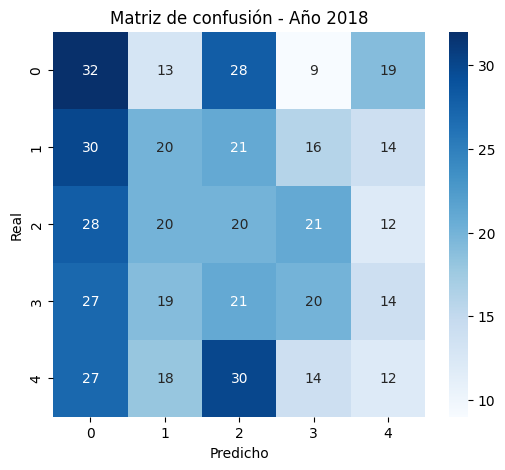

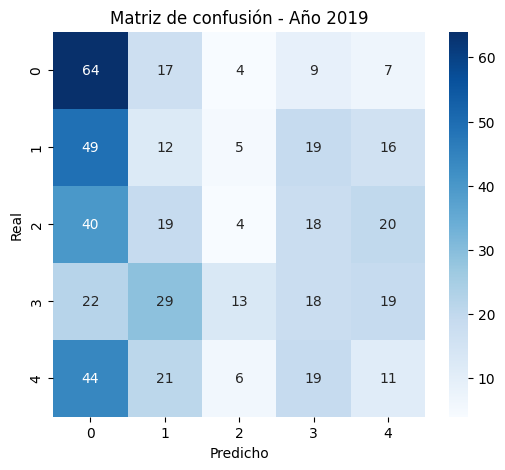

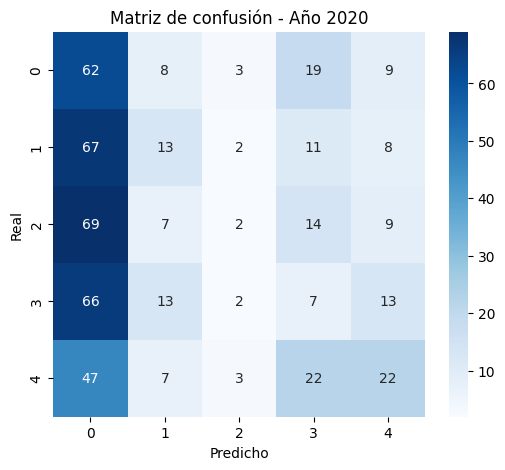

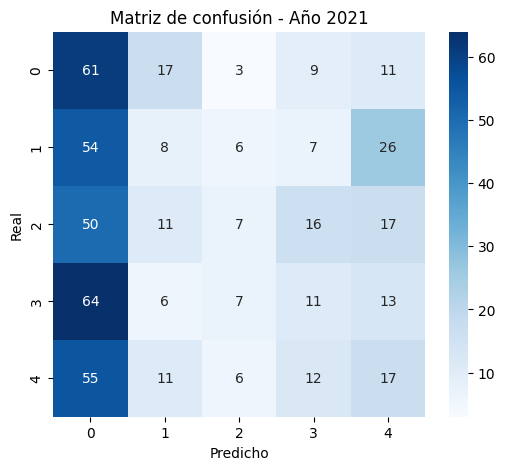

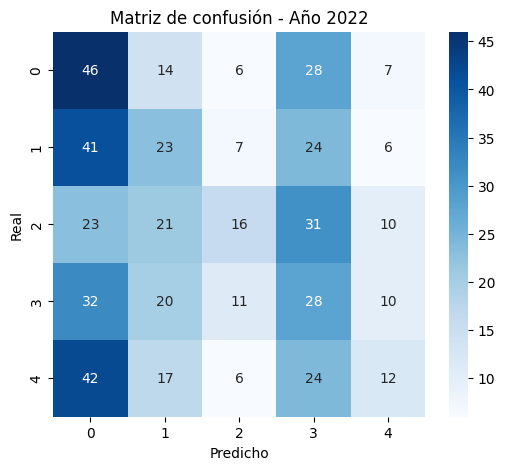

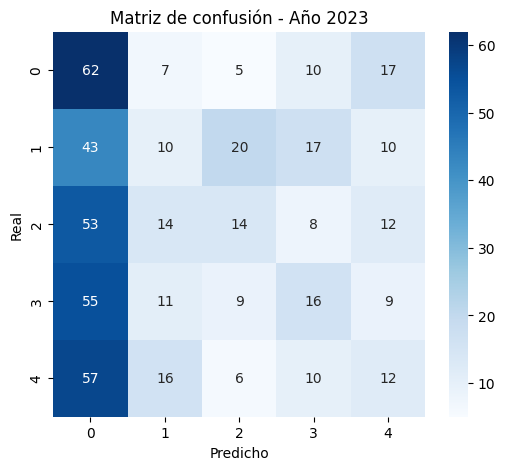

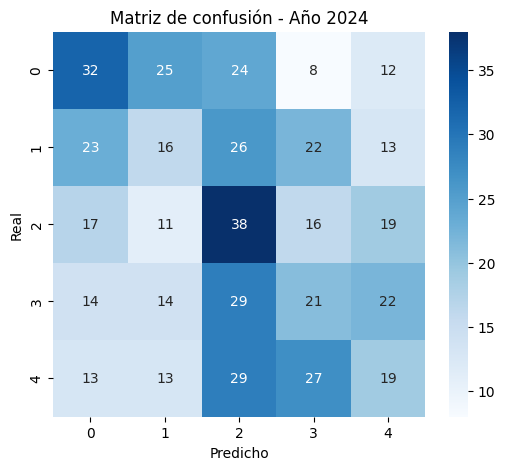

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

for i, row in results_df.iterrows():
    year = row['year']
    conf = np.array(row['confusion_matrix'])

    plt.figure(figsize=(6, 5))
    sns.heatmap(conf, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    plt.title(f"Matriz de confusión - Año {year}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()
